# LangGraph Tutorial
By: Thandokuhle Brian Msane\
_Credit: <a href="https://www.youtube.com/watch?v=jGg_1h0qzaM&"> YouTube Tutorial</a>_

In [ ]:
%pip install langgraph

In [1]:
from typing import TypedDict, Optional, Union, Any, List
from pprint import pprint
import random
from langgraph.graph import StateGraph, START, END



## Type Annotations

Before going further, it'd be best to start off by looking at type annotation and the reason is that most implemenations in LangGraph are based on Type Annotations.

Let's look at a dictionary data structure.

```python
movies = {
    "name": "Avengers Endgame",
    "year": 2019,
    "favourite": True
}
```

Yes dictionaries allow for efficient data retrieval due to the fact that each key in the key-values pairs should be unique so it's easy to identify a particular entity. However, this leads to some challenges in ensuring that the data is a particular structurce.

A solution to this is a TypedDict as given in the example below.

In [ ]:


class Movie(TypedDict):
    name: str
    year: Any # anything and everything is allowed
    sales: Union[int, float, None] = None # The Union type says that the value can take one of the defined types
    favourite: Optional[bool] = True # The Optional type says that an instance is not required to provide the value for this key 

movie1 = Movie(name="Avengers Endgame", year=2019, favourite=True)
pprint(movie1)

{'favourite': True, 'name': 'Avengers Endgame', 'year': 2019}


When using `TypedDict` we define explicitly what the data structure should look like and this helps in reducing runtime errors while making sure that the data is consistent, especially when it belongs to a defined schema. Also, we enhance the readability of the code thereby making debugging much easier.

## LangGraph Elements

1. The **State** is a shared data structure that holds the current information or context of the entire application. In simple terms, it's like the application's memory keeping track of the variables and data that nodes can access and modify as they execute

2. **Nodes** are individual functions or operations that perform specific tasks within the graph. Each node receives input which is often the current state, processes it, and produces an output or an updated state. Within the nodes we can utilize **_Tool_** to perform specific tasks such as fetching data from an API, inserting or querying data from a DB, and many more tasks.

3. A **Graph** is the overaching structure that maps out how differnt nodes are connected and execute. It visually represents the workflow, showing the sequence and conditional paths between various operations.

4. **Edges** are the connections between nodes that determine the flow of executions. They determine which node should be executed next after the current one completes its task. **_Conditional Edges_** are specialized connections that decide the next node to execute based on specific conditions or logic appliet to the current state

5. The **Start Node** is a virtual entry point which marks where the workflow begins, it _doesn't perform any operation itself_ but serves as the designated starting point for the graph's execution.

6. The **End Node** signifies the conclusion of the workflow in LangGraph so upon reaching this node, the graph's executions stops, indicating that all intended processes have been completed.

7. A **ToolNode** is just a special kind of node whose main job is to run a tool. It connects the tool's output back into the State, so other nodes can use that information. 

8. A **StateGraph** is a class in LangGraph used to build and compile the graph structure. It manages the nodes, edges, and the overall state ensuring that the workflow operates in a unified way and that data flows correctly between components.

9. A **Runnable** is a standardized, executable component that performs a specific task within an AI workflow. It serves as a fundamental building block, allowing for us to create modular systems.

10. **Messages**
    - Human Message represents input from the user
    - System Message is used to provide instructions or context to the model
    - Function Message represents the result of a function call
    - AI message represents responses generated by AI models
    - Tool Message is similar to Function Message, but specific to Tool usage

## Graph I


In [ ]:
class AgentState(TypedDict):
    message: str


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state """
    state['message'] = "Hey " + state['message'] + ", how is your day going?"
    return state


graph = StateGraph(state_schema=AgentState)
graph.add_node("Greeter", action=greeting_node)
graph.set_entry_point("Greeter")
graph.set_finish_point("Greeter")

app = graph.compile()

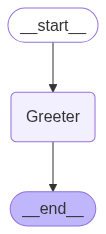

In [18]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke(input={"message": "Bob"})
result['message']

'Hey Bob, how is your day going?'

## Exercise for Graph 1

Task: Create a personalized Compliment Agent using LangGraph.
```
input: {name: "Bob"}
Output: "Bob, you're doing an amazing job learning LangGraph!"
```

{'name': "Bob, you're doing an amazing job learning LangGraph"}
{'name': "Brian, you're doing an amazing job learning LangGraph"}


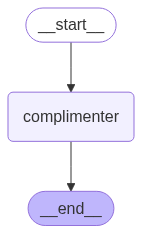

In [28]:

class AgentState(TypedDict):
    name: str
    
graph1 = StateGraph(state_schema=AgentState)

def compliment(state: AgentState) -> AgentState:
    """Compliment the person learning LangGraph"""
    state['name'] = f"{state['name']}, you're doing an amazing job learning LangGraph"
    return state

graph1.add_node("complimenter", action=compliment)
graph1.set_entry_point('complimenter')
graph1.set_finish_point('complimenter')
exercise1 = graph1.compile()

print(exercise1.invoke({"name": "Bob"}))
print(exercise1.invoke({'name': "Brian"}))

display(Image(exercise1.get_graph().draw_mermaid_png()))


## Graph II: Multiple Inputs Graph

The objectives of this secion are:
- define a more complext `AgentState`
- create a processing node that performs operations on list data
- Set up a LangGraph that processes and outputs computed results
- Invoke the graph with structured inputs are retrieve outputs

'Hi there, Thandokuhle Brian Msane! Your sum is:  55'


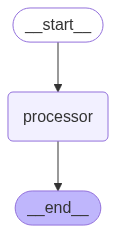

In [43]:

class State(TypedDict):
    values: List[int]
    name: str
    result: Optional[str] = None

def process_values(state: State) -> State:
    """Handling multiple different inputs"""
    state['result'] = f"Hi there, {state['name']}! Your sum is:  {sum(state['values'])}"
    return state

graph2 = StateGraph(state_schema=State)
graph2.add_node("processor", action=process_values)
graph2.set_entry_point('processor')
graph2.set_finish_point('processor')
multiple = graph2.compile()

pprint(multiple.invoke(
    input={
        'values': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'name': "Thandokuhle Brian Msane",
    }
)['result'])

display(Image(multiple.get_graph().draw_mermaid_png()))

## Exercise for Graph II
Task: Create a Graph where you pass a single list of integers along with a name and an operation. If the operation is `+`, you add the elements and if it is a `*`, you multiply the elements.

```python
input = {"name": "Jack", "values": [1,2,3,4], "operation": "*"}
output = "Hi Jack, your answer is: 24"

Hi Brian, your answer is: 49


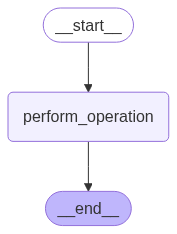

In [ ]:
from functools import reduce
import operator


class StateExercise2(TypedDict):
    name: str
    operation: str
    values: list[int]
    result: str


def perform_operation(state: StateExercise2) -> StateExercise2:
    """Perform the given operation on the given values"""
    if state['operation'] == "+":
        result = sum(state['values'])
    elif state['operation'] == "*":
        result = reduce(operator.mul, state['values'])
    
    state['result'] = f"Hi {state['name']}, your answer is: {result}"
    return state
    
graph3 = StateGraph(StateExercise2)
graph3.add_node('perform_operation', perform_operation)
graph3.set_entry_point('perform_operation')
graph3.set_finish_point('perform_operation')
exercise3 = graph3.compile()

print(exercise3.invoke({
    'name': "Brian",
    'operation': '*',
    'values': [7, 7]
})['result'])


display(Image(exercise3.get_graph().draw_mermaid_png()))

## Graph III: Sequential Graph

The objectives of this Graph are:
- Create multiple nodes that sequentially process and update different parts of the state
- Connect nodes together in a graph
- Invoke the Graph and see how the state is transformed step-by-step


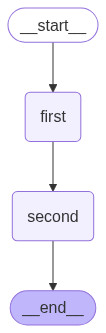

{'age': 99, 'final': 'Hi Brian 👋! You are 99 years old 🤔🧔', 'name': 'Brian'}


In [72]:
class AgentStateThirdGraph(TypedDict):
    name: str
    age: str
    final: Optional[str] = None

def first_node(state: AgentStateThirdGraph) -> AgentStateThirdGraph:
    """This is the first node in our sequence"""
    state['final'] = f"Hi {state['name']} 👋! "
    return state

def second_node(state: AgentStateThirdGraph) -> AgentStateThirdGraph:
    """This is the second node in our sequence"""
    state['final'] += f"You are {state['age']} years old 🤔🧔"
    return state

graph4 = StateGraph(AgentStateThirdGraph)
graph4.add_node('first', first_node)
graph4.add_node('second', second_node)
graph4.set_entry_point('first')
graph4.add_edge('first', 'second')
graph4.set_finish_point('second')

app = graph4.compile()
display(Image(app.get_graph().draw_mermaid_png()))

pprint(app.invoke(input={
    'age': 99,
    'name': "Brian",
}))


## Exercise for Graph III

Task: Accept a user's name, age and a list of skills. Pass the State through three nodes that:
- First node: personalizes teh name field with a greeting
- Second node: describes the user's age
- Third node: lists the skills in a formattted string
The final output in the result field should be a combined message in this format

```python
Output = "Linda, welcone to the system! You are 31 years old! You have skills in Python, Machine learning, and LangGraph"

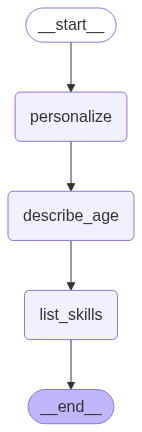

"Kuhle, welcome to the system! You're 23 age years old! You have skills in  Python Machine learning Langgraph"

In [81]:
class ExerciseThreeState(TypedDict):
    name: str
    age: int
    skills: List[str]
    result: str

def personalize_greeting(state: ExerciseThreeState) -> ExerciseThreeState:
    state['result'] = f"{state['name']}, welcome to the system!"
    return state

def describe_age(state: ExerciseThreeState) -> ExerciseThreeState:
    state['result'] += f" You're {str(state['age'])} age years old!"
    return state

def list_skills(state: ExerciseThreeState) -> ExerciseThreeState:
    skills = ""
    for skill in state['skills']:
        skills +=  " " + skill.capitalize()
    state['result'] += f" You have skills in {skills}"
    return state

graph5 = StateGraph(ExerciseThreeState)
graph5.add_node('personalize', personalize_greeting)
graph5.add_node('describe_age', describe_age)
graph5.add_node('list_skills', list_skills)

# add edges to connect nodes
graph5.add_edge('personalize', 'describe_age')
graph5.add_edge('describe_age', 'list_skills')

# define starting and endpoints
graph5.set_entry_point('personalize')
graph5.set_finish_point('describe_age')

app = graph5.compile()
display(Image(app.get_graph().draw_mermaid_png()))

app.invoke(input={
    'name': "Kuhle",
    'age': 23,
    'skills': ['python', 'machine learning', 'langgraph']
})['result']

## Graph IV: Conditional Graph
The objectives of thes section are:

- implement conditional logic to route the flow of data to different node
- Uses START and END nodes to manage entry and exit points explicitly.
- design multiple nodes to perform differnt operations
- create a router node to handle decision-making and control graph flow


In [ ]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    final_number: Optional[int] = None


def adder(state: AgentState) -> AgentState:
    """Add two numbers"""
    state['final_number'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """Subtract two numbers"""
    state['final_number'] = state['number1'] - state['number2']
    return state

def other_operation(state: AgentState) -> AgentState:
    """Implement other operation which is not addition or subtraction"""
    
    if state['operation'] == "*":
        state['final_number'] = state['number1'] * state['number2']
    elif state['operation'] == "/":
        state['final_number'] = state['number1'] / state['number2']
    elif state['operation'] == "//":
        state['final_number'] = state['number1'] // state['number2']
    
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""
    
    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "-":
        return "subtraction_operation"
    return 'other_operation'
    
graph = StateGraph(AgentState)
graph.add_node('subtract_node', subtractor)
graph.add_node("add_node", adder)
graph.add_node('router', lambda state: state) # passthrough function
graph.add_node('other_node', other_operation)

graph.add_edge(START, 'router')
graph.add_conditional_edges(
    source='router',
    path=decide_next_node,
    path_map={
        # in the format Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node",
        'other_operation': "other_node"
    }
)
graph.add_edge('add_node', END)
graph.add_edge('subtract_node', END)
graph.add_edge('other_node', END)

app = graph.compile()
# display(Image(app.get_graph().draw_mermaid_png()))


print(
    app.invoke(
        input=AgentState(
            number1=5,
            number2=2,
            operation='//',
            final_number=None
        )
))


{'number1': 5, 'operation': '//', 'number2': 2, 'final_number': 2}


## Exercise for Graph IV

Task: Make a graph with 2 conditional edges
```python
input = AgentState(
    number1=10,
    opeartion="-",
    number2=7,
    number3=5,
    number4=2,
    operation2="+",
    final_number=0,
    final_number2=0,
)
```
_The solution is given below. The docstrings are missing for now_ 🥹🥹🌞

In [ ]:
class ExerciseFourState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    final_number1: int
    final_number2: int
    
def decide_operation_node1(state: ExerciseFourState) -> ExerciseFourState:
    if state['operation1'] == "+":
        return "add_operation"
    elif state['operation1'] == "-":
        return "subtraction_operation"

def decide_operation_node2(state: ExerciseFourState) -> ExerciseFourState:
    if state['operation2'] == "+":
        return "add_operation"
    elif state['operation2'] == "-":
        return "subtraction_operation"

# we need to perform python overloading

def add_operation1(state: ExerciseFourState) -> ExerciseFourState:
    state['final_number1'] = state['number1'] + state['number2']
    return state

def subtract_operation1(state: ExerciseFourState) -> ExerciseFourState:
    state['final_number1'] = state['number1'] - state['number2']    
    return state

def add_operation2(state: ExerciseFourState) -> ExerciseFourState:
    state['final_number2'] = state['number3'] + state['number4']
    return state

def subtract_operation2(state: ExerciseFourState) -> ExerciseFourState:
    state['final_number2'] = state['number3'] - state['number4']
    return state

graph = StateGraph(ExerciseFourState)

graph.add_node('add_node1', add_operation1)
graph.add_node('subtract_node1', subtract_operation1)
graph.add_node('add_node2', add_operation2)
graph.add_node('subtract_node2', subtract_operation2)
graph.add_node('router1', lambda state: state)
graph.add_node('router2', lambda state: state)

graph.add_edge(START, 'router1')
graph.add_conditional_edges(
    source='router1',
    path=decide_operation_node1,
    path_map={
        "add_operation": "add_node1",
        'subtraction_operation': "subtract_node1"
    }
)
graph.add_edge('add_node1', 'router2')
graph.add_edge('subtract_node1', 'router2')

graph.add_conditional_edges(
    source='router2',
    path=decide_operation_node2,
    path_map={
        "add_operation": "add_node2",
        'subtraction_operation': "subtract_node2"
    }
)

graph.add_edge('add_node2', END)
graph.add_edge('subtract_node2', END)

app = graph.compile()
app.invoke(
    input=ExerciseFourState(
        number1=10,
        number2=7,
        number3=5,
        number4=2,
        operation1='-',
        operation2='+'
    )
)

{'number1': 10,
 'number2': 7,
 'number3': 5,
 'number4': 2,
 'operation1': '-',
 'operation2': '+',
 'final_number1': 3,
 'final_number2': 7}

## Graph V: Looping Graph

The objectives of this section are:
- implement **_looping logic_** to router the flow of data back to the nodes
- create a single conditional edges to handle decision-making and control graph flow

In [ ]:
class AgentState(TypedDict):
    name: str
    numbers: Optional[list[int]]=[]
    counter: Optional[int]=None


def greeting_node(state: AgentState) -> AgentState:
    """Greeting node which says hi to the person"""
    state['name'] = f"Hi there {state['name']}"
    state['counter'] = 0
    return state


def random_node(state: AgentState) -> AgentState:
    """Generate a random number from 0 to 10"""
    state['numbers'].append(random.randint(0, 10))
    state['counter'] += 1
    return state


def should_continue(state: AgentState) -> AgentState:
    """Decide what to do next"""
    if state['counter'] < 5:
        return 'loop'
    return 'exit'

graph = StateGraph(AgentState)
graph.add_node('greeting_node', greeting_node)
graph.add_node('random_node', random_node)

graph.add_edge(START, 'greeting_node')
graph.add_edge('greeting_node', 'random_node')
graph.add_conditional_edges(
    'random_node',
    should_continue,
    {
        'loop': 'random_node',
        'exit': END
    }
)

app = graph.compile()
pprint(app.invoke(
    input=AgentState(
        name='Brian',
        numbers=[],
        counter=5
    )
))

{'counter': 5, 'name': 'Hi there Brian', 'numbers': [6, 9, 9, 9, 0]}


## Execise V: The guessing game 🎯

Task: You are given a task to guess an unknown number and each time you guess you can either guess a lower, higher, or exact value and a hint should be given as per your guess. When you correctly guess the number, you should then exit because you have won 🏆

- let's stick to positive numbers which are less than 100 in this game 🌞

In [ ]:
class GuessingState(TypedDict):
    number: int
    guess: Optional[int] = None
    hint: Optional[str] = ""

def guess(state: GuessingState) -> GuessingState:
    """
    Guess the number with the help of the hint
    Let's assume that lower means that try a lower number and higher means try a higher number
    """
    print(state['hint'])
    if state['hint'] == 'lower':
        state['guess'] = random.choice(range(0, state['guess']))
    elif state['hint'] == 'higher':
        state['guess'] = random.choice(range(state['guess'], 100))
    
    if state['guess'] > state['number']:
        state['hint'] = 'lower'
    elif state['guess'] < state['number']:
        state['hint'] = 'higher'
    else:
        state['hint'] = 'equal'
        
    return state

def play(state: GuessingState) -> GuessingState:
    """Decide if I have won or lost"""
    print(state['guess'])
    if state['guess'] == state['number'] and state['hint'] == 'equal':
        return 'won'
    return 'lost'

graph = StateGraph(GuessingState)
graph.add_node('guess', guess)

graph.add_edge(START, 'guess')
graph.add_conditional_edges(
    source='guess',
    path=play,
    path_map={
        'lost': "guess",
        'won': END
    }
)

app = graph.compile()
app.invoke(
    GuessingState(
        number=7,
        guess=0,
        hint='no_hint_at_first',
    ),
    {"recursion_limit": 100}
)


no_hint_at_first
0
higher
26
lower
11
lower
9
lower
2
higher
74
lower
20
lower
18
lower
16
lower
8
lower
3
higher
42
lower
37
lower
6
higher
7


{'number': 7, 'guess': 7, 'hint': 'equal'}